In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import random_sample
from scipy.ndimage import label

### Уравнение, аналитическое и численное решения
Рассмотрим простейший СДУ ИТО - Геометрическое Броуновское движение

В символической форме записи

$dX_t = \mu X_t dt + \sigma X_t dW_t$

Аналитическое решение

$X_t = X_0 \exp((\mu - \frac{\sigma^2}{2}) + \sigma W_t)$

Метод Эйлера сразу выписывается

$X_n = X_{n-1} + \mu X_{n-1} dt + \sigma X_{n-1} dW_{n-1}$

А вот метод Мильштейна выглядит уже следующим образом

$X_n = X_{n-1} + \mu X_{n-1} dt + \sigma X_{n-1} dW_{n-1} + \frac{1}{2} 
\sigma^2 X_{n-1}(dW_{n-1}^2 - dt)$




### Поправка к методу Мильштейна

Процесс $X_t$ - процесс Ито если удовлетворяет СДУ
$dX_t = a(t, X_t)\,dt + b(t, X_t)\,dW_t,$

Запишем формулу Ито для F(x, t) в интегральной форме

$F(t_{n+1}, X_{t_{n+1}}) - F(t_n, X_{t_n}) = \int_{t_n}^{t_{n+1}} \left( \frac{\partial F}{\partial s} + a\frac{\partial F}{\partial x} + \frac{1}{2}b^2\frac{\partial^2 F}{\partial x^2} \right)ds + \int_{t_n}^{t_{n+1}} b\frac{\partial F}{\partial x}\,dW_s$



Рассмотрим произвольное СДУ Ито на некотором промежутке $[t_n, t_{n+1}]$

$X_{t_{n+1}} = X_{t_n} + \int_{t_n}^{t_{n+1}} a(s, X_s)\,ds + \int_{t_n}^{t_{n+1}} b(s, X_s)\,dW_s.$

Применим формулу Ито к диффузионному члену

$b(s, X_s) = b(t_n, X_n) + \int_{t_n}^s \left( \frac{\partial b}{\partial u} + a\frac{\partial b}{\partial x} + \frac{1}{2}b^2\frac{\partial^2 b}{\partial x^2} \right)du + \int_{t_n}^s b\frac{\partial b}{\partial x}\,dW_u$

$\int_{t_n}^{t_{n+1}} b(s, X_s)\,dW_s = b(t_n, X_n)\Delta W_n 
+ \int_{t_n}^{t_{n+1}}\Biggl( \int_{t_n}^s \Bigl( \frac{\partial b}{\partial u} + a\frac{\partial b}{\partial x} + \frac{1}{2}b^2\frac{\partial^2 b}{\partial x^2} \Bigr)du \Biggr)dW_s
+ \int_{t_n}^{t_{n+1}}\Biggl( \int_{t_n}^s b\frac{\partial b}{\partial x}\,dW_u \Biggr)dW_s $

Вторым членом можно пренебречь

$\int_{t_n}^{t_{n+1}} b(s, X_s)\,dW_s = b(t_n, X_n)\Delta W_n 
+ \int_{t_n}^{t_{n+1}}\Biggl( \int_{t_n}^s b\frac{\partial b}{\partial x}\,dW_u \Biggr)dW_s $

Подынтегральную функцию третьего интеграла заффикисруем на левом конце, так как внутри она меняется медленно и получим

$b(t_n,X_n)\frac{\partial b}{\partial x}(t_n,X_n)\int_{t_n}^{t_{n+1}}(W_s - W_{t_n})dWs$

Применив формулу ито к функции $\frac12(W_s - W_{t_n})^2 $ получаем значение стохастического интеграла. Итоговая поправка имеет вид

$\frac12 b\frac{\partial b}{\partial x} \bigl( (\Delta W_n)^2 - \Delta t \bigr)$


Применительно к нашей задаче $b = \sigma x$

$\frac{1}{2} \sigma^2 X_{n-1}(\Delta W_{n-1}^2 - dt)$



In [78]:
# Параметры
T = 2.0
N = 100
dt = T / N
mu = 1.5
sigma = 0.8
x0 = 1.0

t = np.linspace(0, T, N + 1)
np.random.seed(42)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.insert(np.cumsum(dW), 0, 0)

In [83]:
def Analytic(t, x0):
    return x0*np.exp((mu - sigma**2/2)*t + sigma*W)

def Euler(t, x0):
    Xt = np.zeros(N+1) + x0
    for i in range(1,len(t)):
        Xt[i] = Xt[i-1] + mu*Xt[i-1]*dt + sigma*Xt[i-1]*dW[i-1]
    return Xt

def Miltishein(t, x0):
    Xt = np.zeros(N+1) + x0
    for i in range(1,len(t)):
        Xt[i] = Xt[i-1] + mu*Xt[i-1]*dt + sigma*Xt[i-1]*dW[i-1] + 0.5*(sigma**2)*Xt[i-1]*(dW[i-1]**2 - dt)
    return Xt
        
    

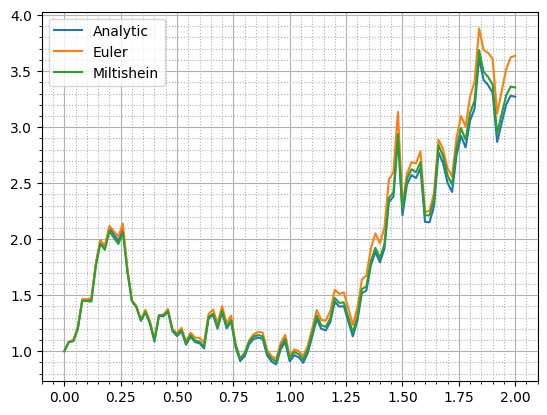

In [85]:
A_Xt = Analytic(t, 1)
E_Xt = Euler(t, A_Xt)
M_Xt = Miltishein(t, A_Xt)

plt.plot(t,A_Xt, label='Analytic')
plt.plot(t,E_Xt, label='Euler')
plt.plot(t,M_Xt, label='Miltishein')
plt.legend()
plt.grid(which='major', axis='both', linestyle='-')
plt.grid(which='minor', axis='both', linestyle=':')
plt.minorticks_on()
plt.show()